# Lecture 3 — Augmentations & Generalization (Examples Notebook)

This notebook is **practice-only**: it demonstrates common augmentation families used in Computer Vision **in real projects**.

What you’ll get:
- A **taxonomy** of augmentation types (geometric, photometric, noise/blur, occlusion, weather/artifacts, etc.)
- Visual examples for each transform (single transform + composed pipelines)
- Examples where augmentations are applied **consistently** to **image + mask + bounding boxes**

Tip: If an augmentation makes your sample look like it belongs to *another task*, it’s probably too aggressive 🙂


In [4]:
# Install (Colab usually has most of this, but let's be safe)
!pip -q install albumentations==1.4.18 opencv-python-headless matplotlib pillow


In [2]:
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import albumentations as A

plt.rcParams["figure.dpi"] = 140

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        A.set_seed(seed)
    except Exception:
        pass

seed_everything(42)

def bgr_to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def show_images(images, titles=None, cols=4, figsize=(12, 7)):
    n = len(images)
    cols = min(cols, n)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        ax = plt.subplot(rows, cols, i + 1)
        ax.axis("off")
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=9)
        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
    plt.tight_layout()
    plt.show()

def draw_bboxes_rgb(img_rgb, bboxes_xyxy, color=(0, 255, 0), thickness=2):
    img = img_rgb.copy()
    for (x1, y1, x2, y2) in bboxes_xyxy:
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), color, thickness)
    return img

def overlay_mask(img_rgb, mask, alpha=0.4):
    overlay = img_rgb.copy()
    colored = np.zeros_like(img_rgb)
    colored[..., 0] = 255  # red channel
    overlay = np.where(mask[..., None].astype(bool), (1-alpha)*overlay + alpha*colored, overlay)
    return overlay.astype(np.uint8)


/home/alex/anaconda3/envs/torch-clean/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 1) Create a synthetic scene (image + mask + bounding boxes)

We avoid internet downloads (offline-friendly). The synthetic scene is enough to show how transforms behave.


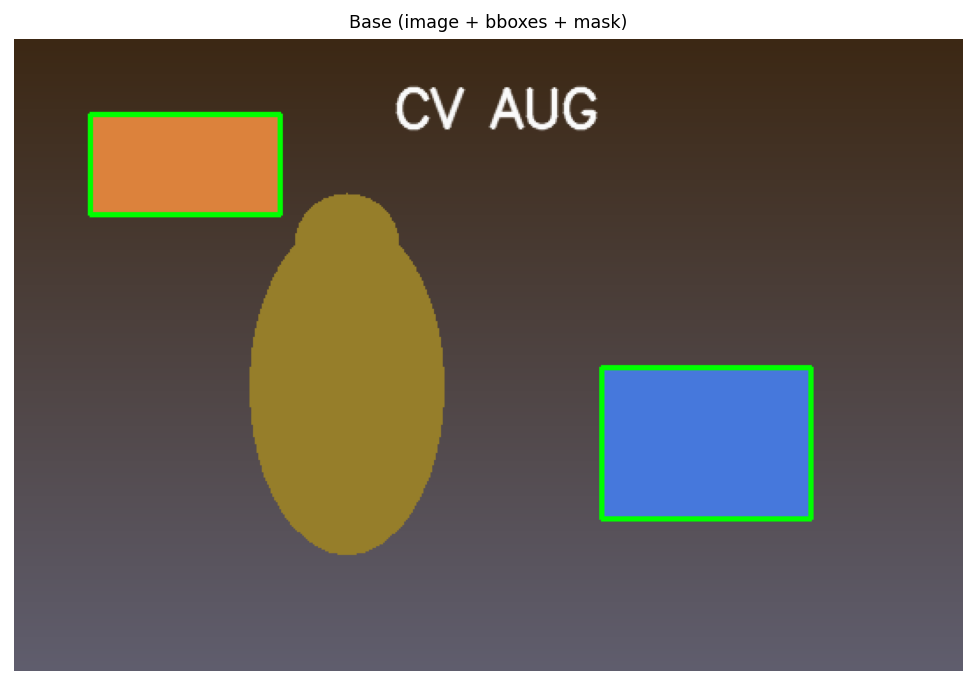

In [5]:
def make_synthetic_scene(h=360, w=540):
    img = np.zeros((h, w, 3), dtype=np.uint8)

    # background gradient
    for y in range(h):
        img[y, :, 0] = np.clip(20 + y * 0.25, 0, 255)  # B
        img[y, :, 1] = np.clip(40 + y * 0.15, 0, 255)  # G
        img[y, :, 2] = np.clip(60 + y * 0.10, 0, 255)  # R

    # draw a "person-like" blob (mask target)
    mask = np.zeros((h, w), dtype=np.uint8)
    center = (int(w*0.35), int(h*0.55))
    cv2.ellipse(mask, center, (55, 95), 0, 0, 360, 1, -1)
    cv2.circle(mask, (center[0], int(h*0.33)), 30, 1, -1)

    # paint blob on image
    img[mask.astype(bool)] = (70, 210, 80)  # BGR

    # add two objects (boxes targets)
    boxes = []
    x1, y1, x2, y2 = int(w*0.62), int(h*0.52), int(w*0.84), int(h*0.76)
    cv2.rectangle(img, (x1, y1), (x2, y2), (220, 120, 70), -1)
    boxes.append([x1, y1, x2, y2])

    x1, y1, x2, y2 = int(w*0.08), int(h*0.12), int(w*0.28), int(h*0.28)
    cv2.rectangle(img, (x1, y1), (x2, y2), (60, 130, 220), -1)
    boxes.append([x1, y1, x2, y2])

    cv2.putText(img, "CV AUG", (int(w*0.40), int(h*0.14)), cv2.FONT_HERSHEY_SIMPLEX,
                1.0, (250, 250, 250), 2, cv2.LINE_AA)

    return img, mask, boxes

img_bgr, mask, boxes_xyxy = make_synthetic_scene()
img_rgb = bgr_to_rgb(img_bgr)

base_vis = overlay_mask(draw_bboxes_rgb(img_rgb, boxes_xyxy), mask)
show_images([base_vis], ["Base (image + bboxes + mask)"], cols=1, figsize=(10, 5))


## 2) Single-transform examples

We apply transforms to **image + mask + bboxes** consistently and visualize.


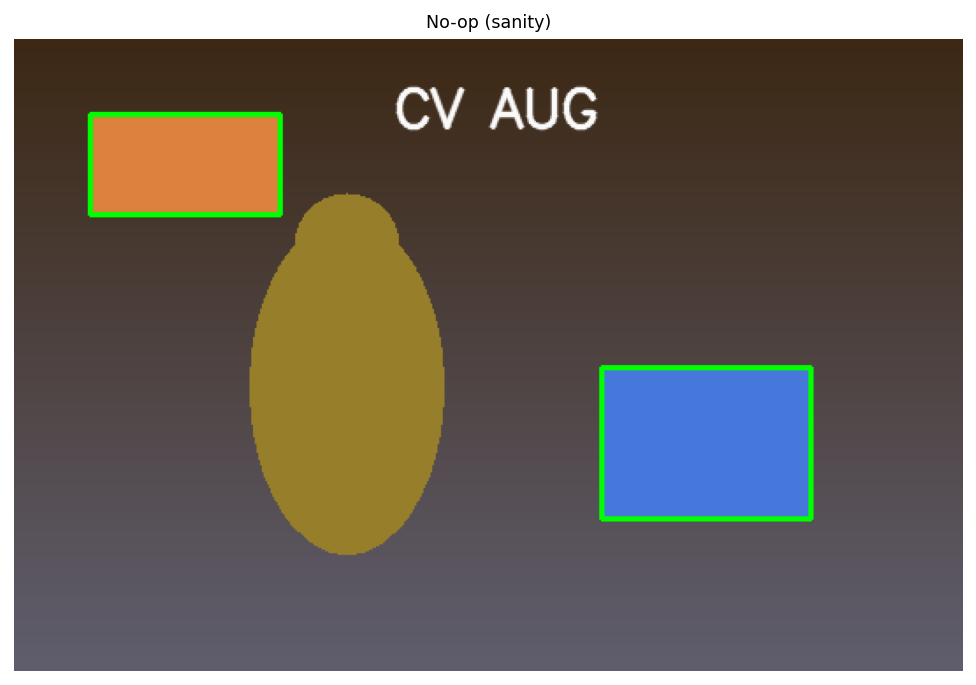

In [6]:
def apply_transform(transform: A.BasicTransform, img_rgb, mask, boxes_xyxy):
    aug = A.Compose(
        [transform],
        bbox_params=A.BboxParams(format="pascal_voc", label_fields=["labels"]),
    )
    data = aug(image=img_rgb, mask=mask, bboxes=boxes_xyxy, labels=[0]*len(boxes_xyxy))
    return data["image"], data["mask"], data["bboxes"]

def show_aug(title, transform):
    out_img, out_mask, out_boxes = apply_transform(transform, img_rgb, mask, boxes_xyxy)
    vis = overlay_mask(draw_bboxes_rgb(out_img, out_boxes), out_mask)
    show_images([vis], [title], cols=1, figsize=(10, 5))

show_aug("No-op (sanity)", A.NoOp())


### 2.1 Geometric transforms
Flip/rotate/affine/perspective/distortions.


/tmp/ipykernel_62323/4252760075.py:9: UserWarning: Argument 'alpha_affine' is not valid and will be ignored.
  ("ElasticTransform", A.ElasticTransform(alpha=40, sigma=6, alpha_affine=8, p=1.0)),


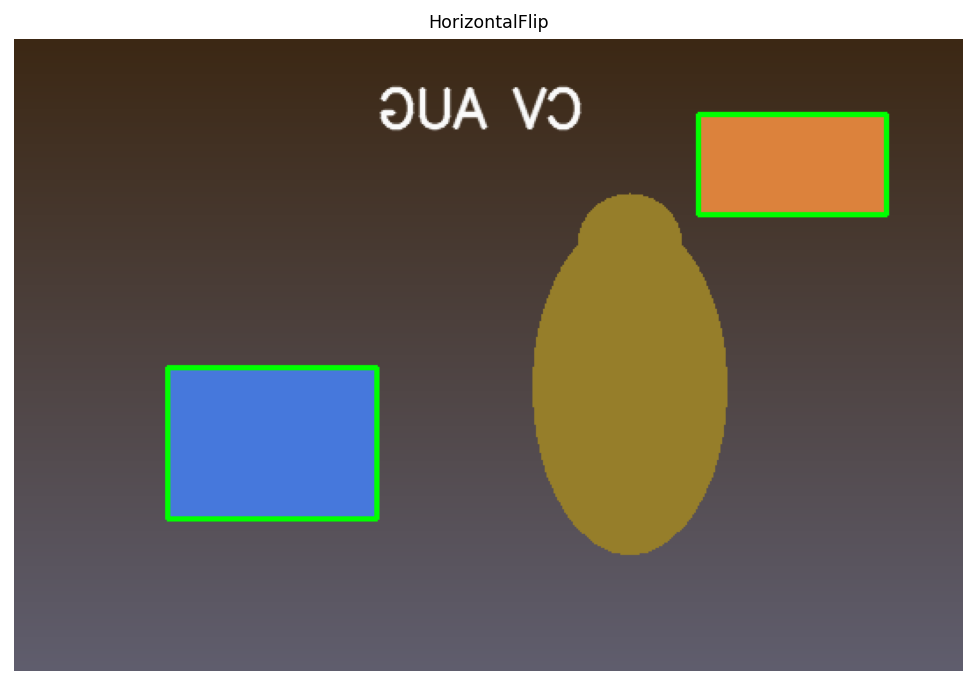

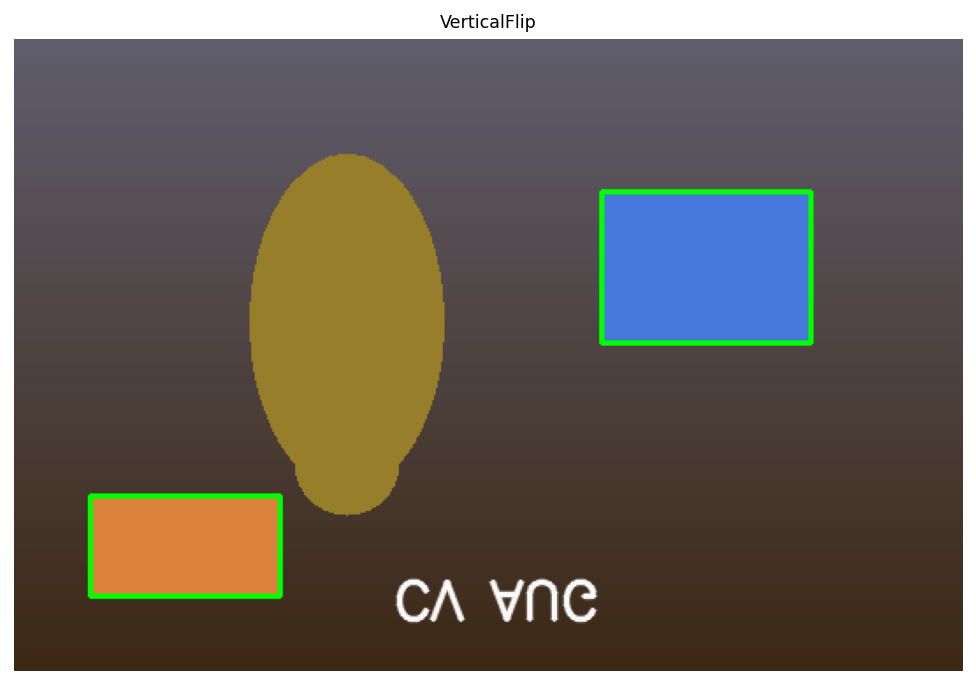

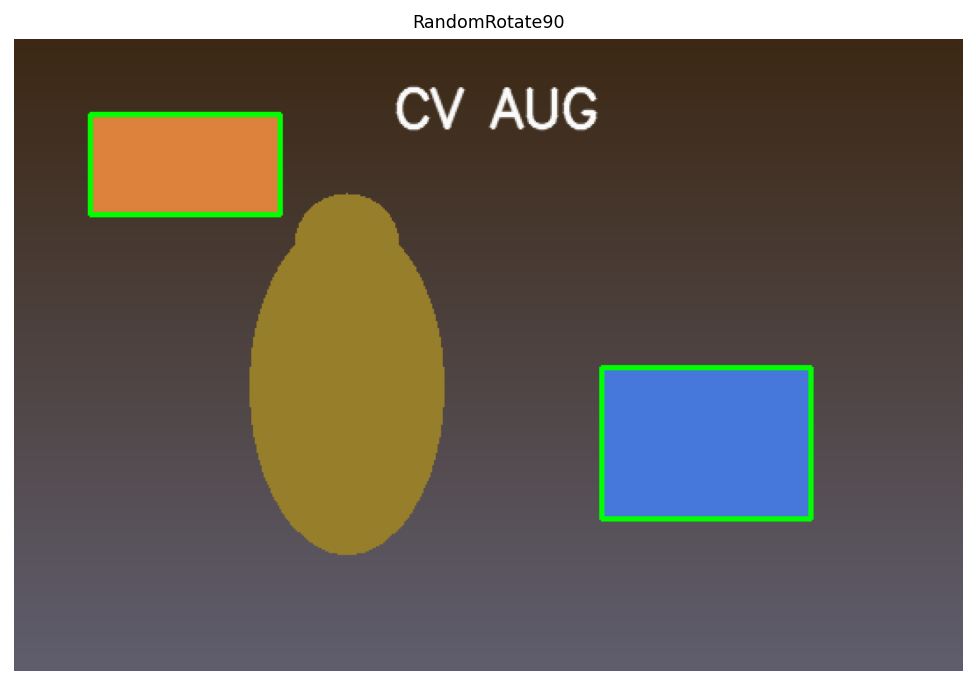

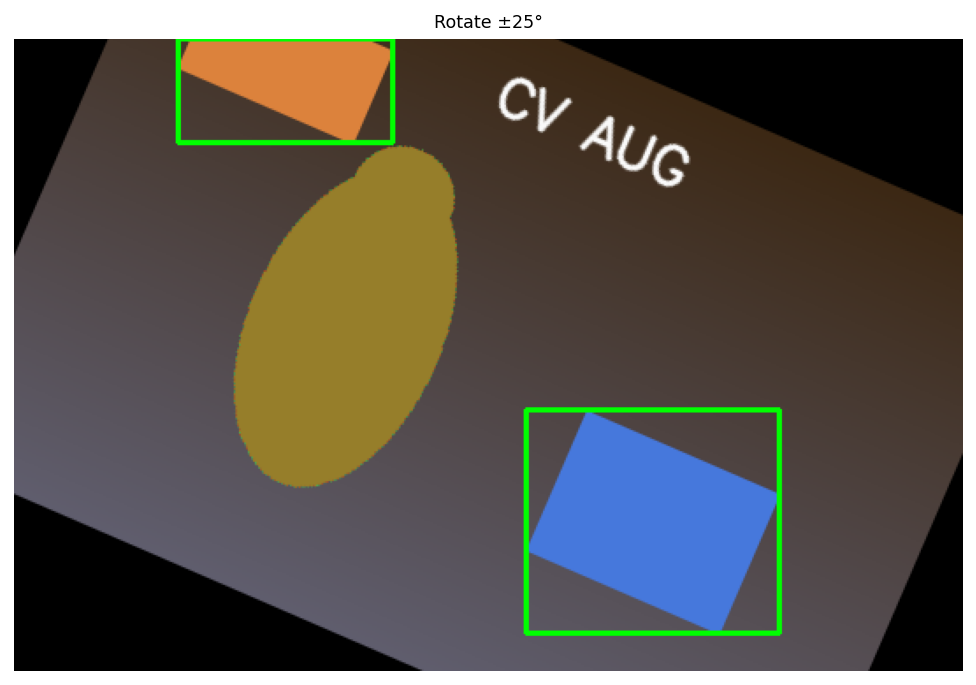

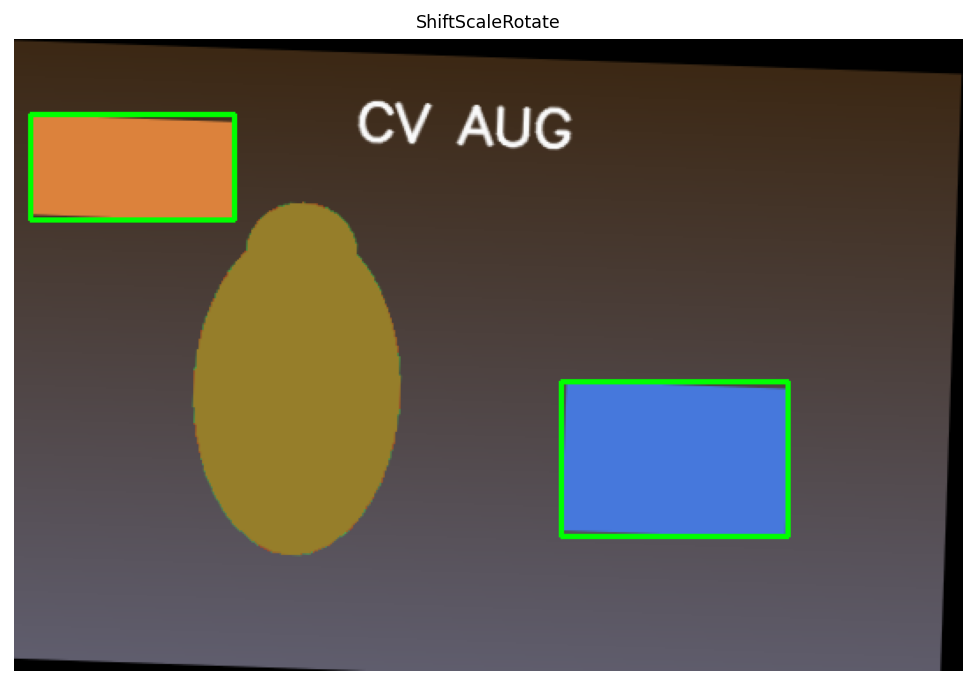

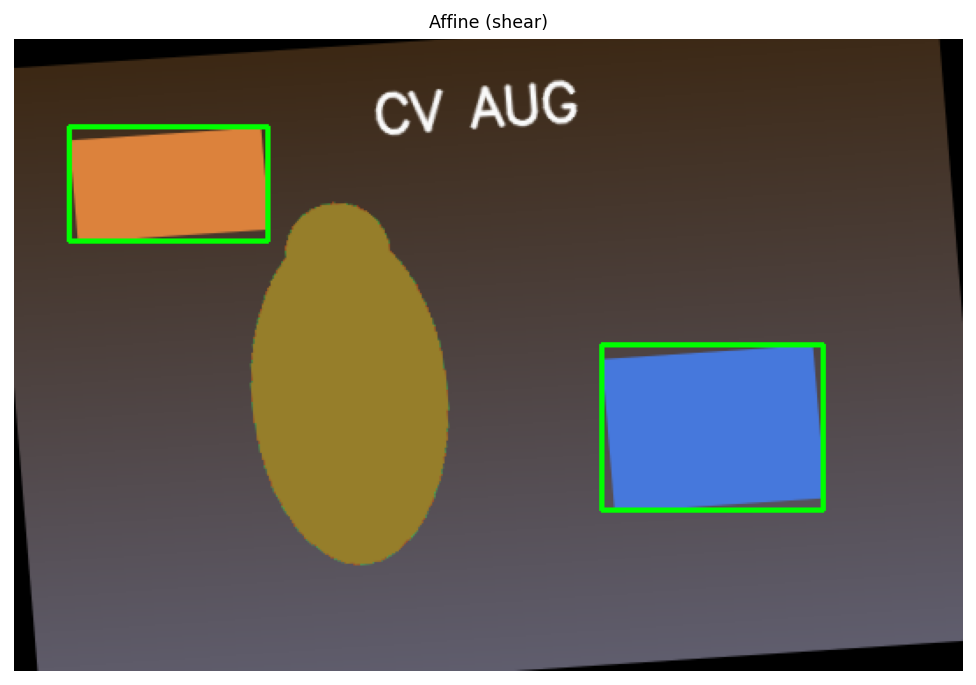

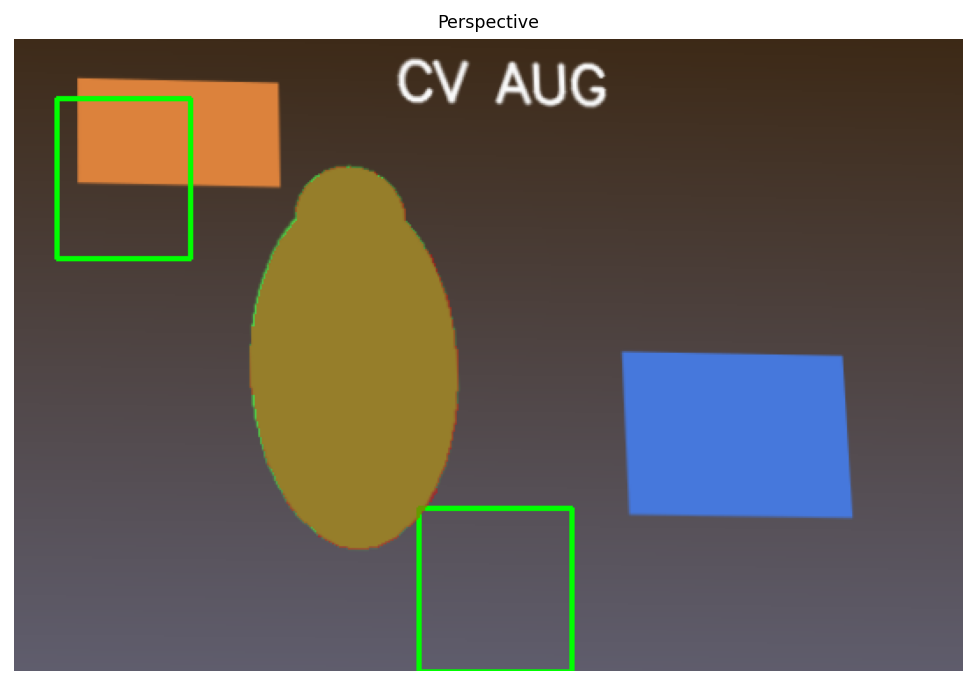

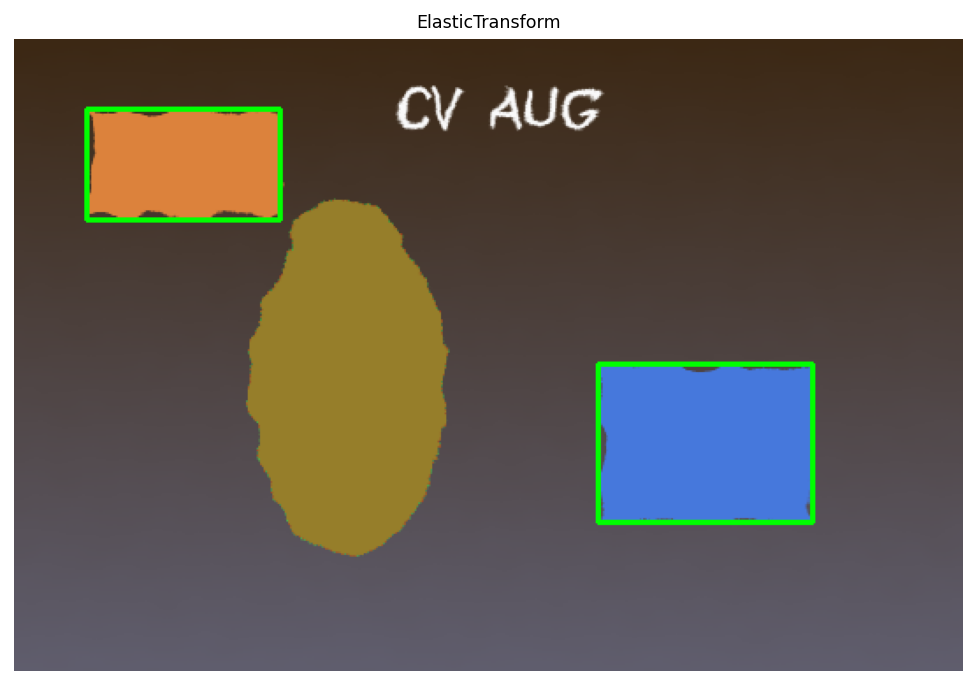

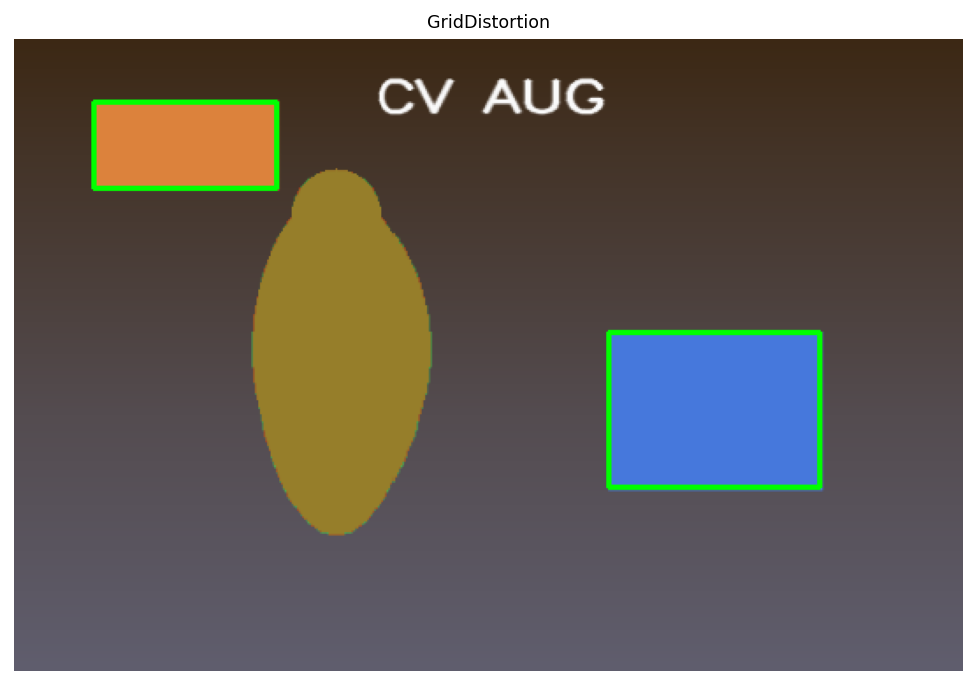

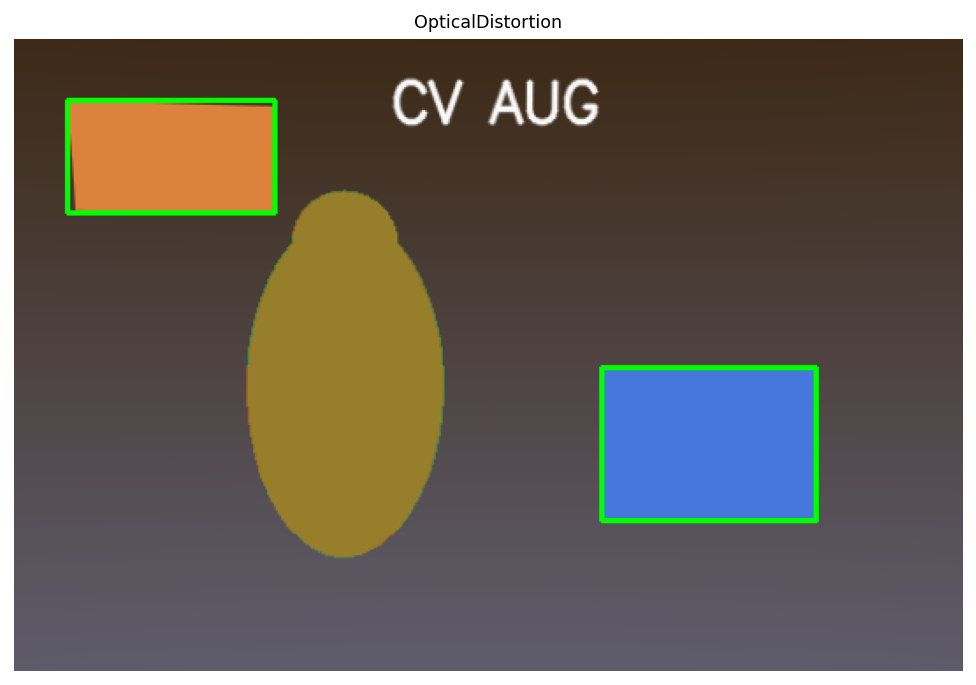

In [7]:
geo_transforms = [
    ("HorizontalFlip", A.HorizontalFlip(p=1.0)),
    ("VerticalFlip", A.VerticalFlip(p=1.0)),
    ("RandomRotate90", A.RandomRotate90(p=1.0)),
    ("Rotate ±25°", A.Rotate(limit=25, p=1.0, border_mode=cv2.BORDER_CONSTANT)),
    ("ShiftScaleRotate", A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=20, p=1.0, border_mode=cv2.BORDER_CONSTANT)),
    ("Affine (shear)", A.Affine(shear=(-12, 12), p=1.0, mode=cv2.BORDER_CONSTANT)),
    ("Perspective", A.Perspective(scale=(0.03, 0.09), p=1.0)),
    ("ElasticTransform", A.ElasticTransform(alpha=40, sigma=6, alpha_affine=8, p=1.0)),
    ("GridDistortion", A.GridDistortion(num_steps=5, distort_limit=0.25, p=1.0)),
    ("OpticalDistortion", A.OpticalDistortion(distort_limit=0.2, shift_limit=0.05, p=1.0)),
]
for name, t in geo_transforms:
    show_aug(name, t)


### 2.2 Resize / Crop / Pad
Standardize input size, but keep an eye on label validity.


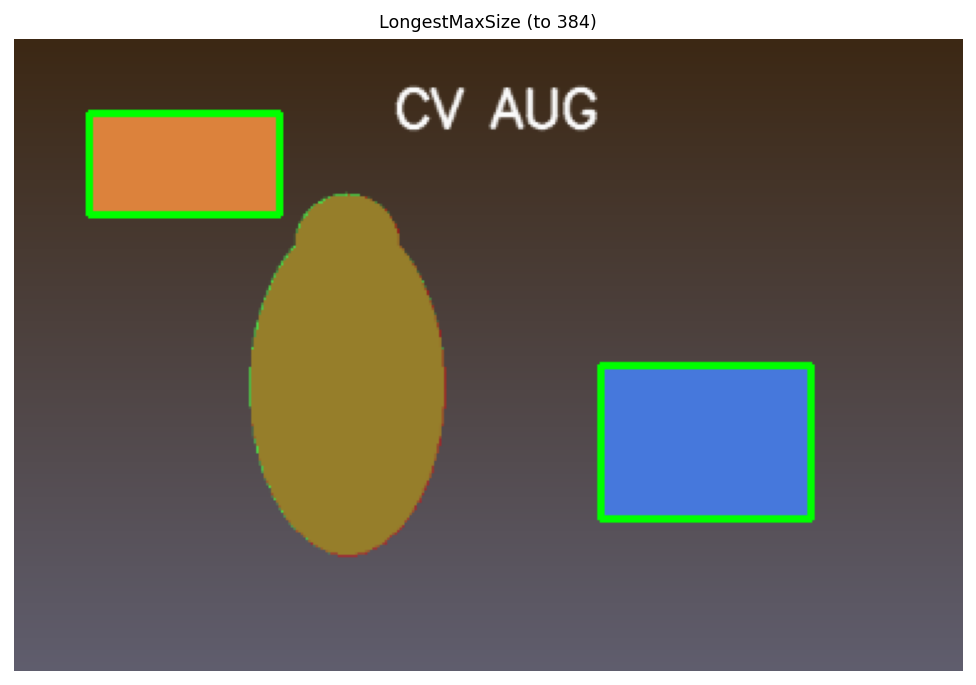

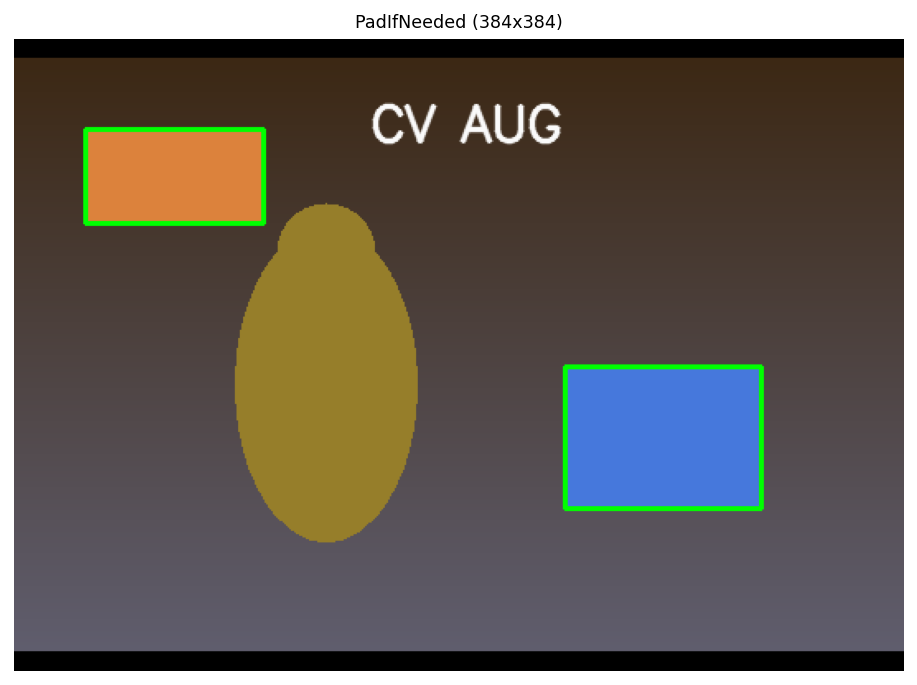

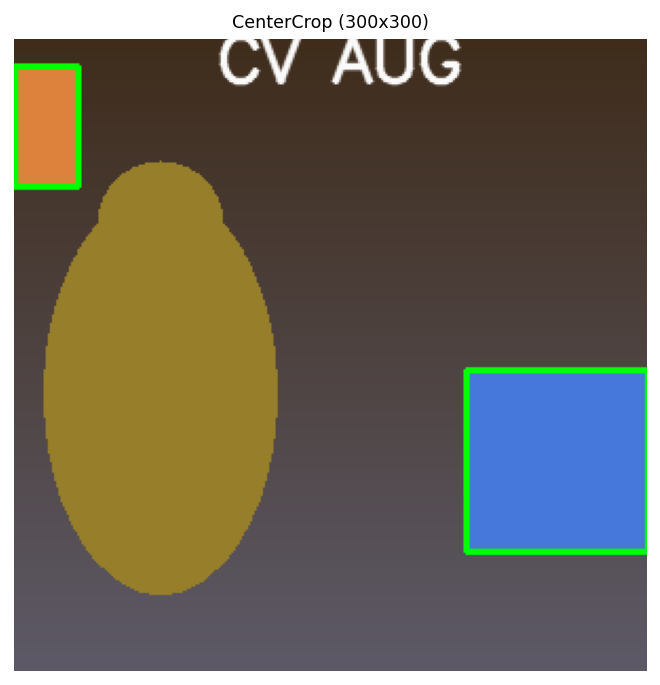

/home/alex/anaconda3/envs/torch-clean/lib/python3.10/site-packages/albumentations/core/bbox_utils.py:476: RuntimeWarning: invalid value encountered in divide
  & (clipped_box_areas / denormalized_box_areas >= min_visibility - epsilon)


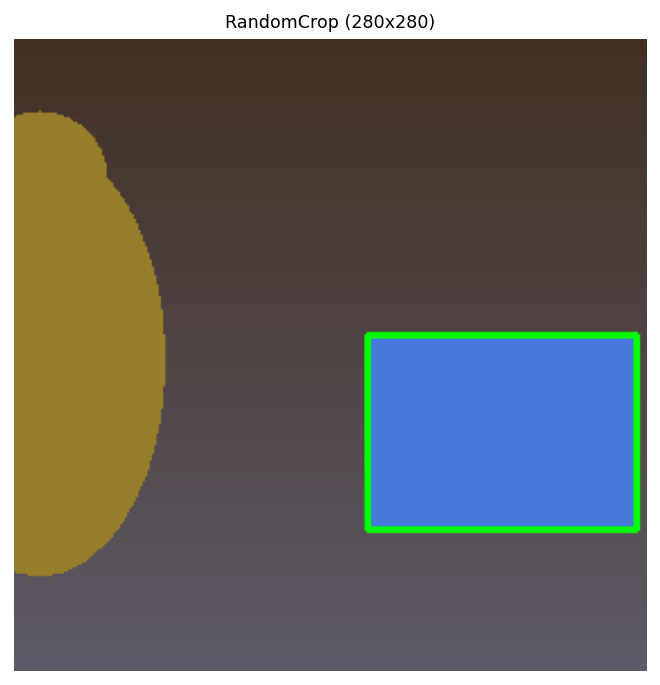

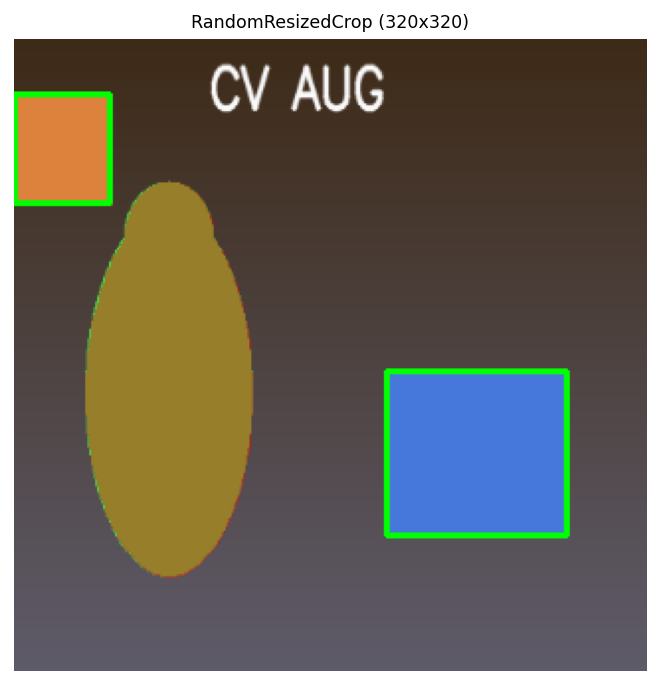

In [8]:
resize_crop_pad = [
    ("LongestMaxSize (to 384)", A.LongestMaxSize(max_size=384, p=1.0)),
    ("PadIfNeeded (384x384)", A.PadIfNeeded(min_height=384, min_width=384, border_mode=cv2.BORDER_CONSTANT, value=(0,0,0), p=1.0)),
    ("CenterCrop (300x300)", A.CenterCrop(height=300, width=300, p=1.0)),
    ("RandomCrop (280x280)", A.RandomCrop(height=280, width=280, p=1.0)),
    ("RandomResizedCrop (320x320)", A.RandomResizedCrop(height=320, width=320, scale=(0.6, 1.0), ratio=(0.75, 1.33), p=1.0)),
]
for name, t in resize_crop_pad:
    show_aug(name, t)


### 2.3 Photometric / color transforms
Brightness/contrast, gamma, HSV, channel tricks, etc.


/home/alex/anaconda3/envs/torch-clean/lib/python3.10/site-packages/albumentations/core/composition.py:192: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


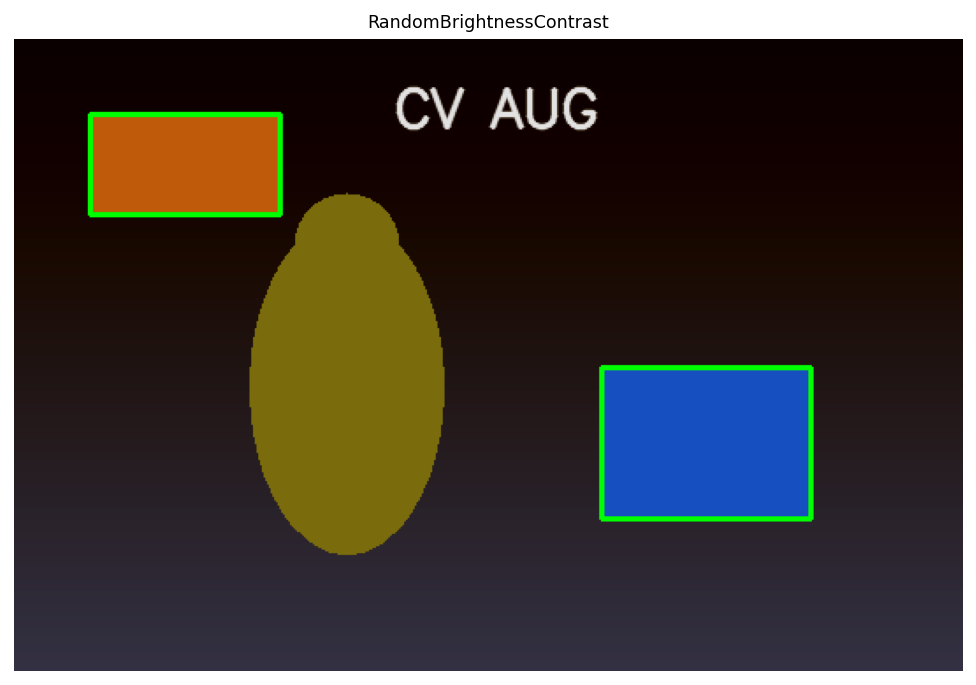

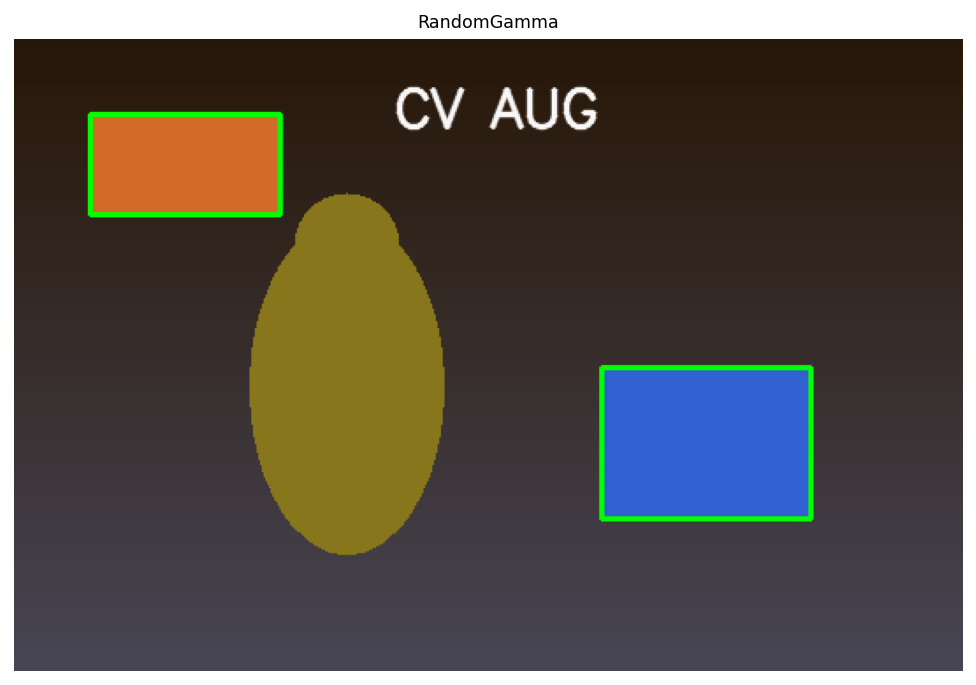

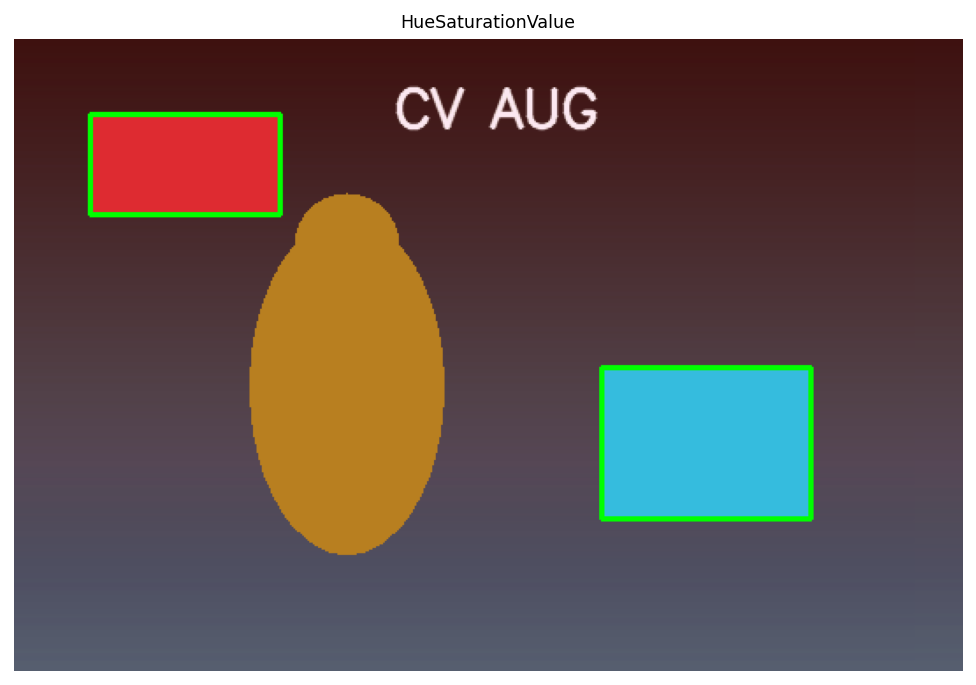

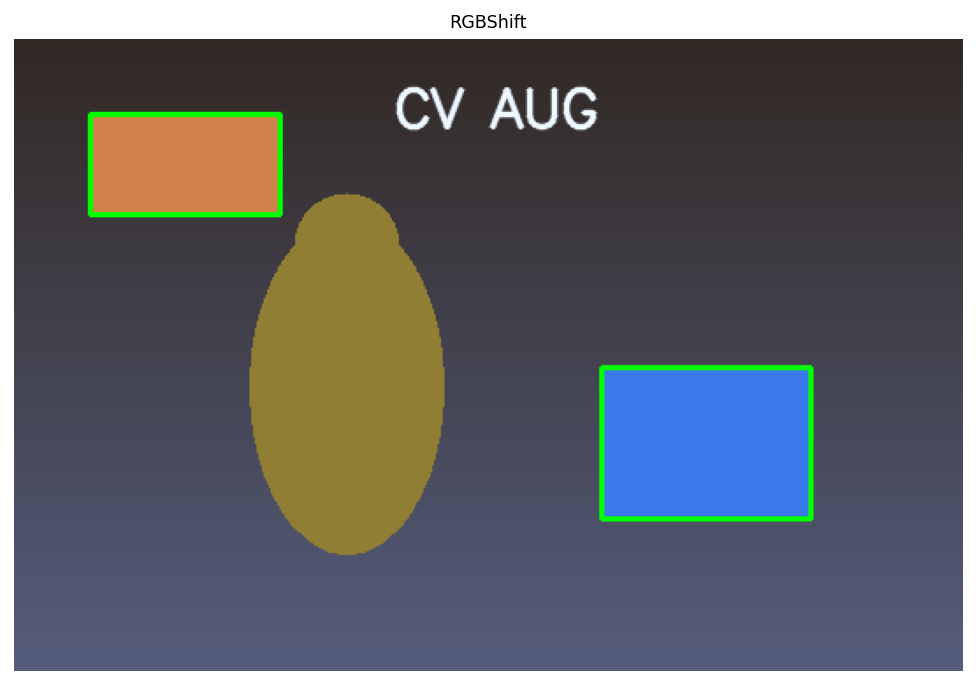

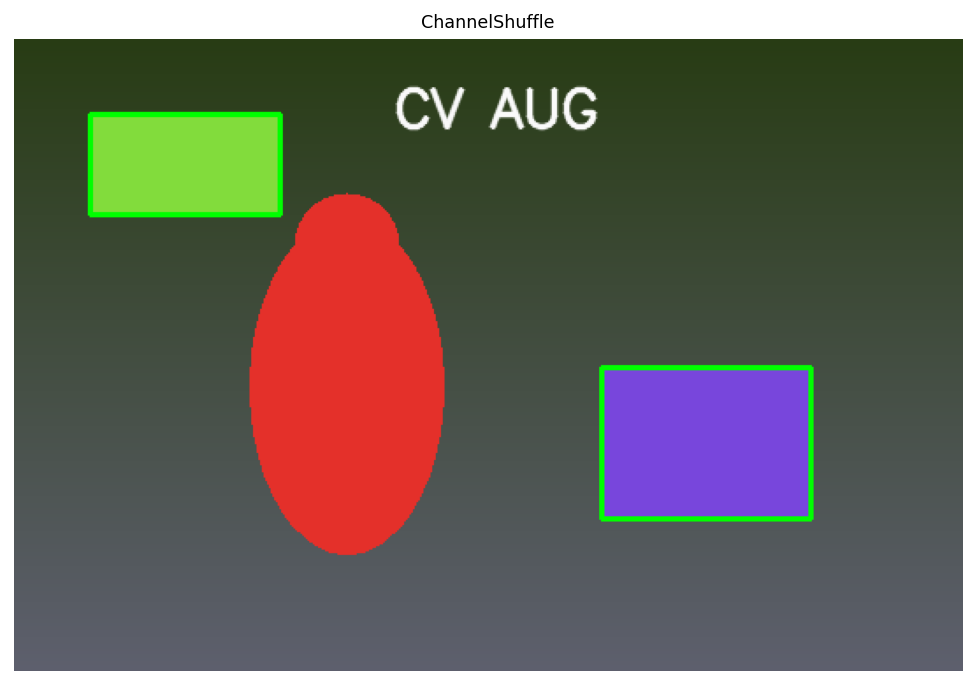

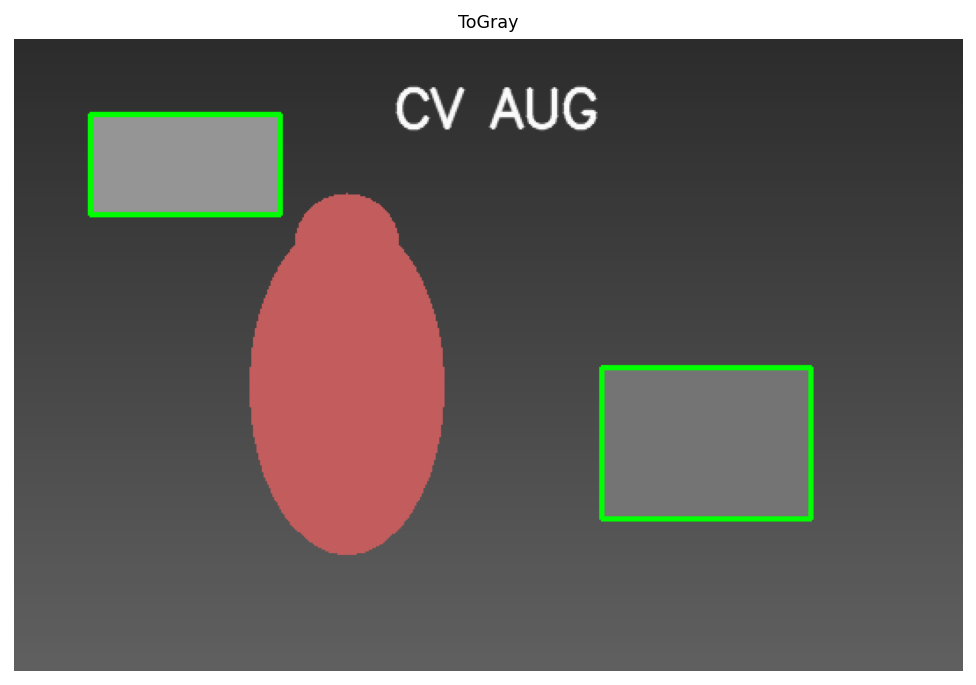

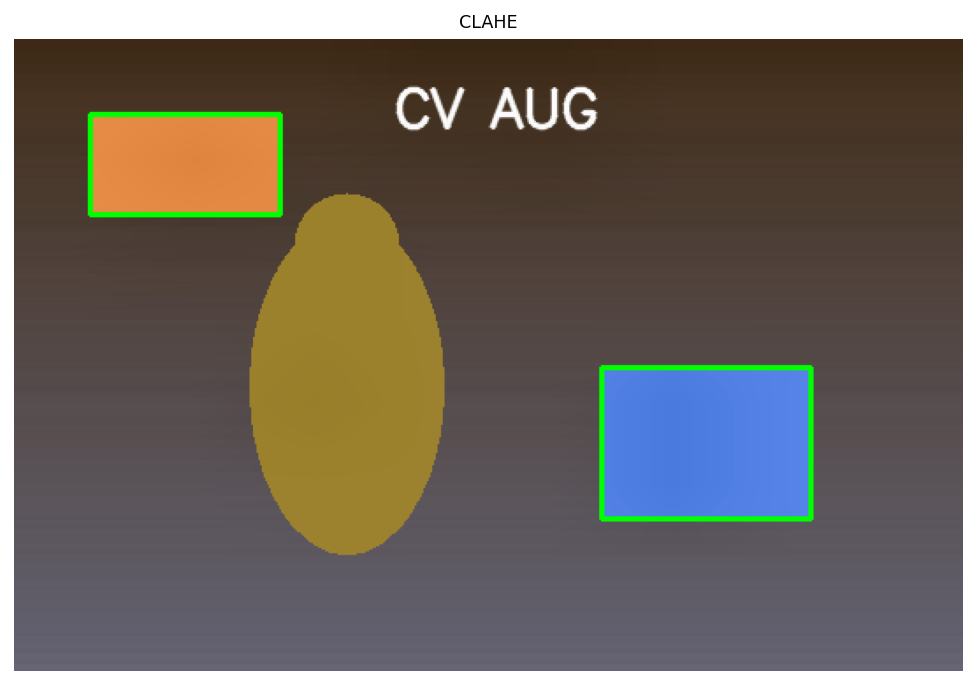

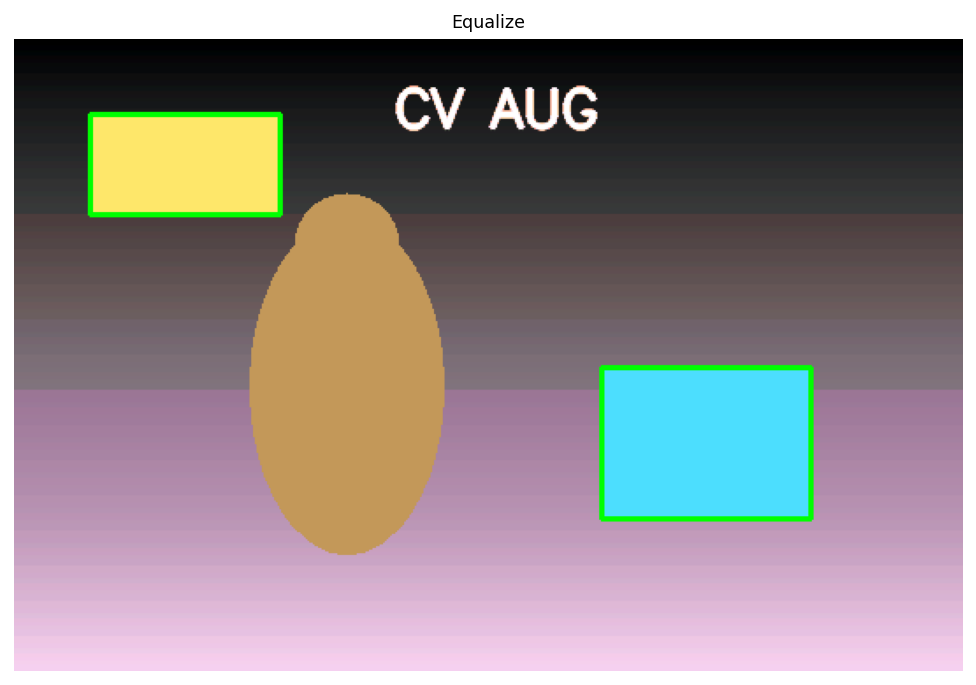

In [9]:
photo_transforms = [
    ("RandomBrightnessContrast", A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=1.0)),
    ("RandomGamma", A.RandomGamma(gamma_limit=(80, 140), p=1.0)),
    ("HueSaturationValue", A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=15, p=1.0)),
    ("RGBShift", A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=1.0)),
    ("ChannelShuffle", A.ChannelShuffle(p=1.0)),
    ("ToGray", A.ToGray(p=1.0)),
    ("CLAHE", A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)),
    ("Equalize", A.Equalize(p=1.0)),
]
for name, t in photo_transforms:
    show_aug(name, t)


### 2.4 Blur / noise / artifacts
Sensor noise, motion blur, compression, downscale.


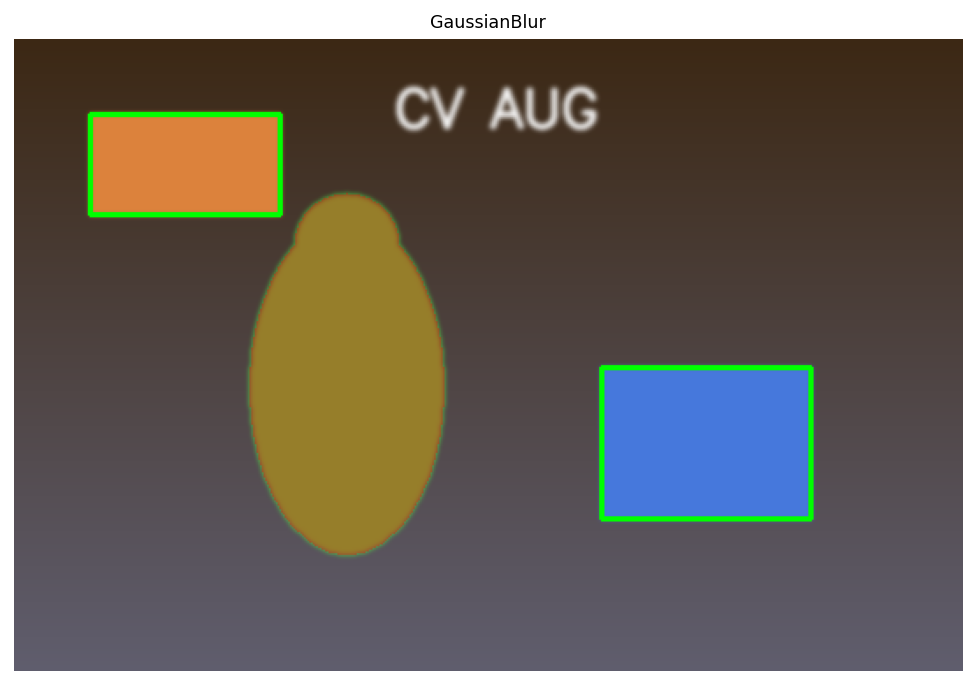

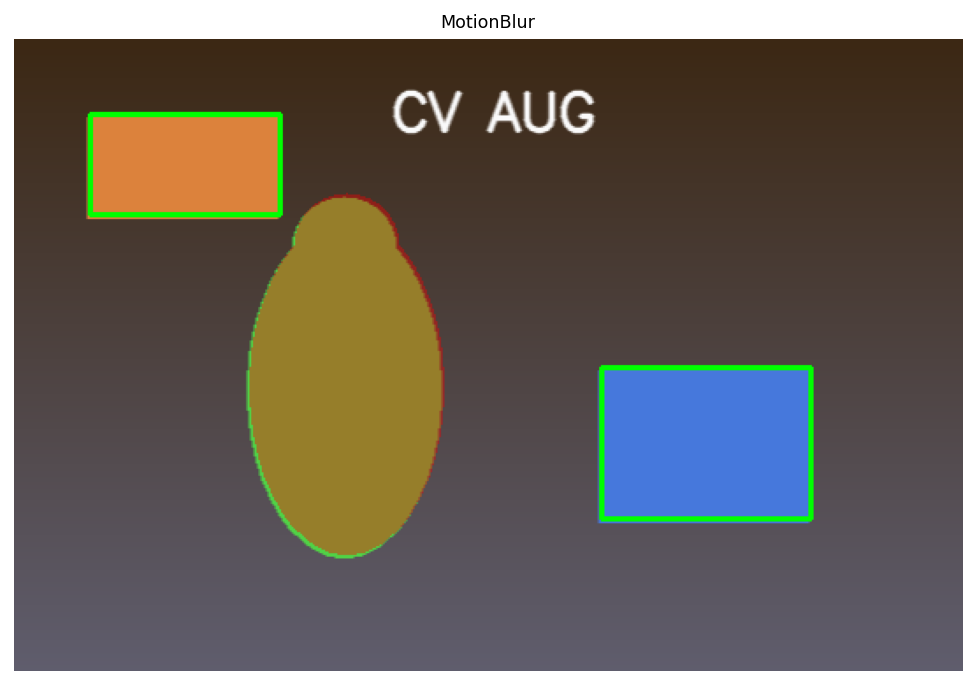

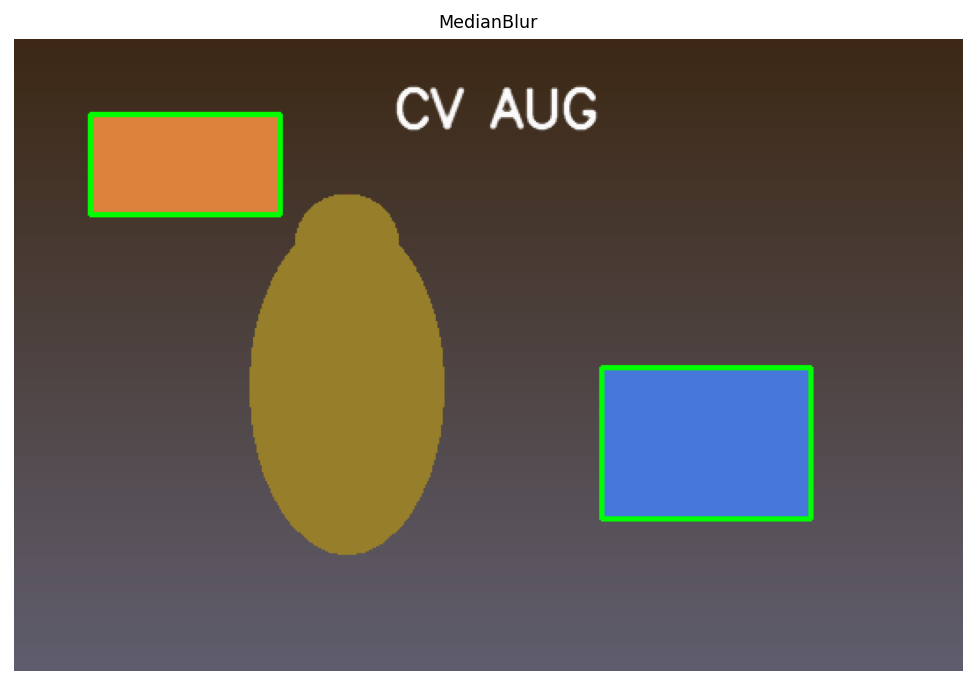

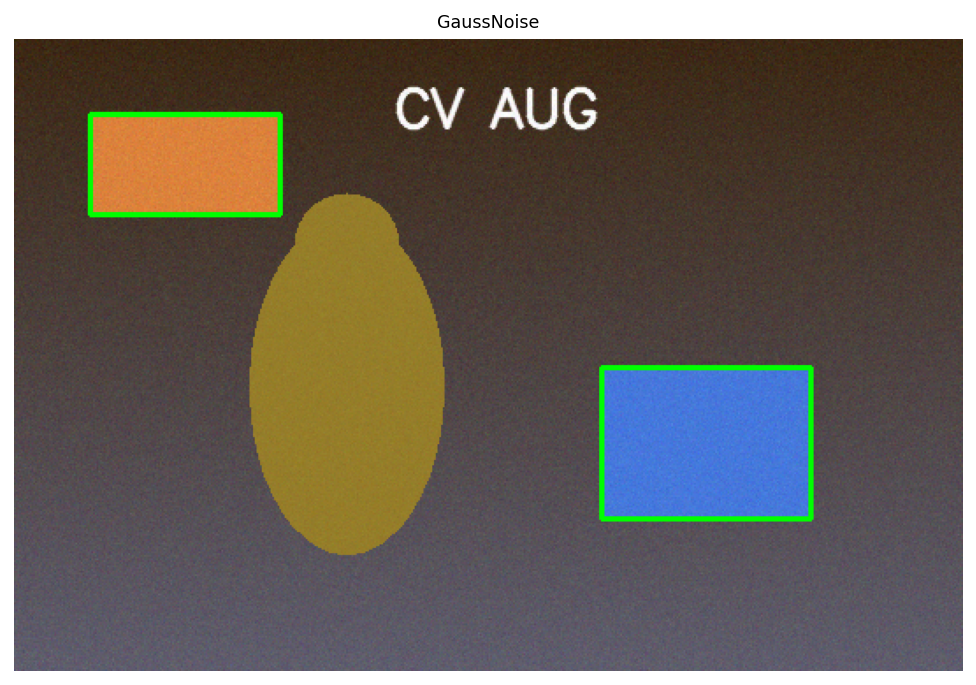

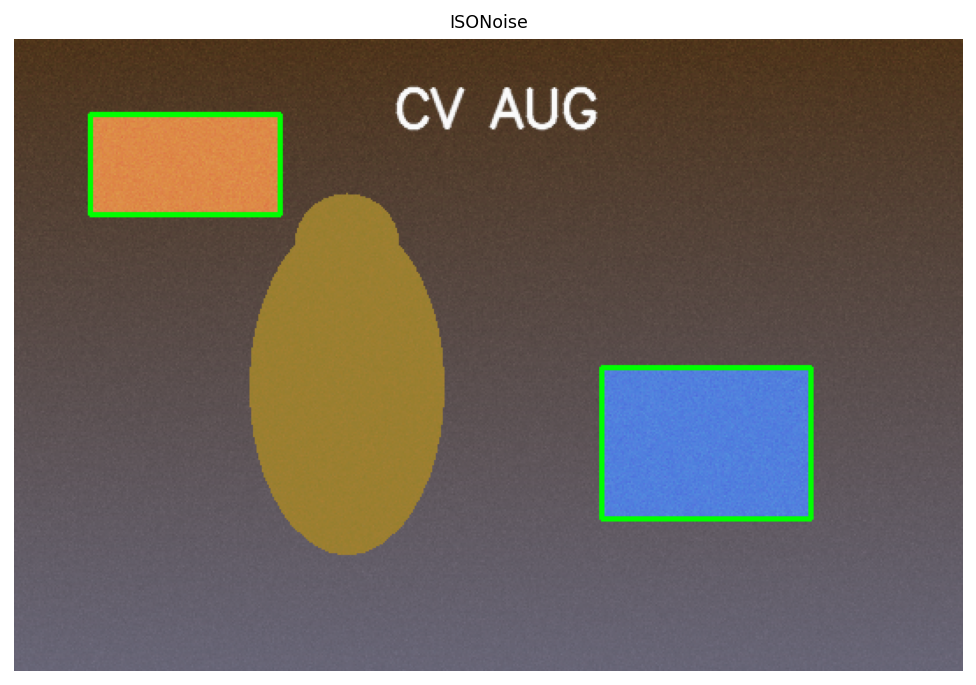

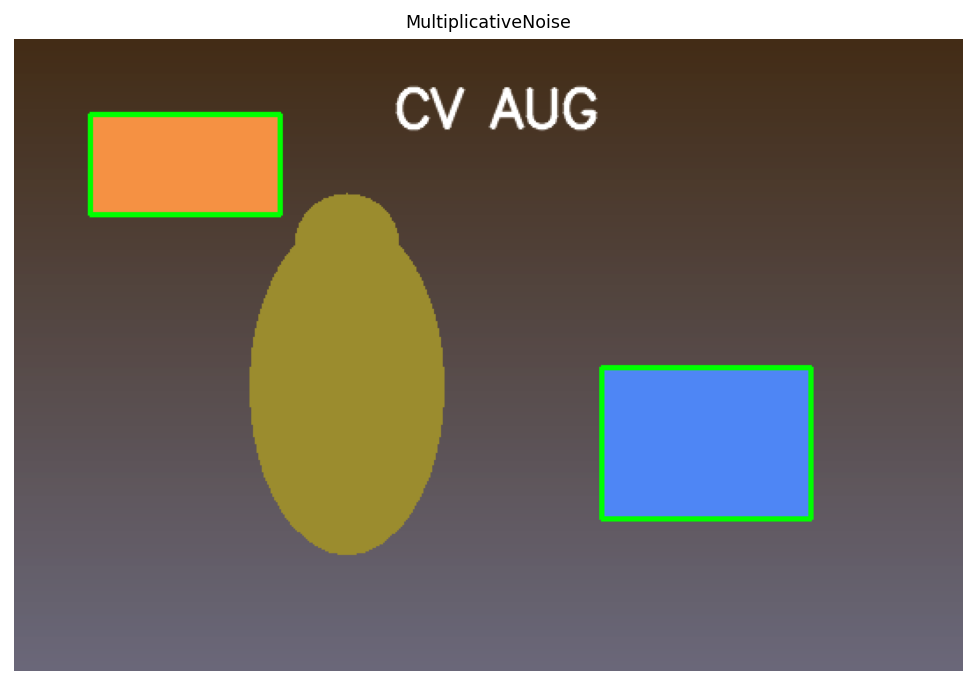

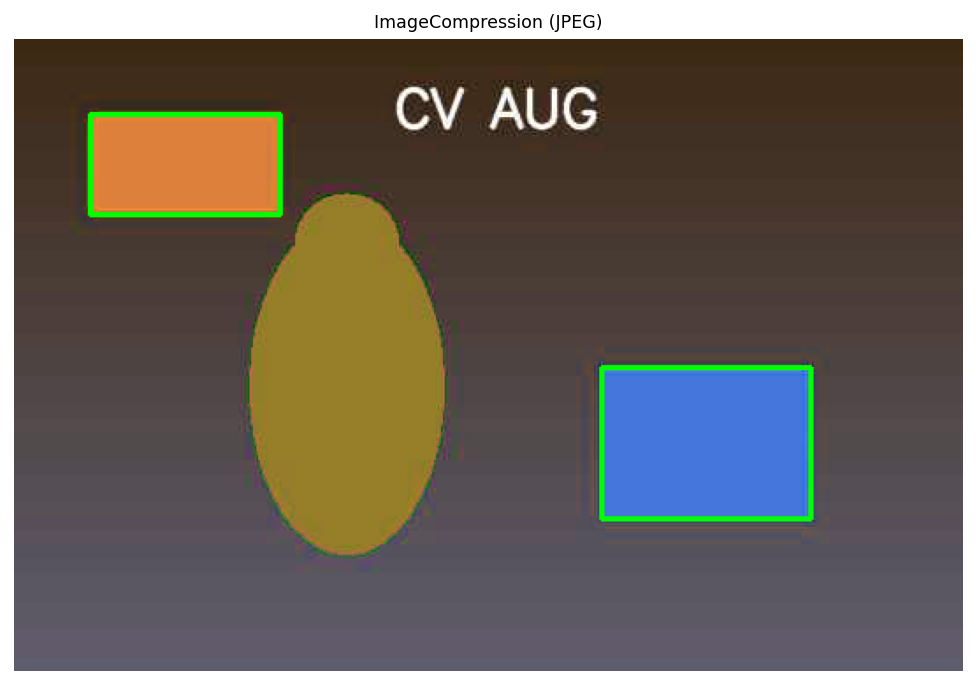

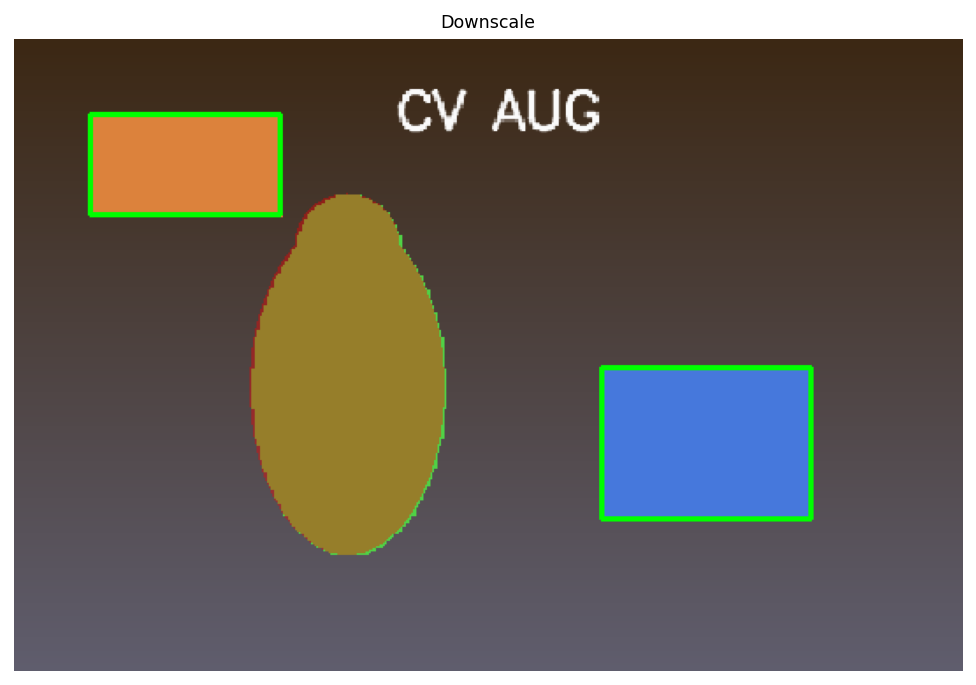

In [10]:
noise_blur = [
    ("GaussianBlur", A.GaussianBlur(blur_limit=(3, 9), p=1.0)),
    ("MotionBlur", A.MotionBlur(blur_limit=11, p=1.0)),
    ("MedianBlur", A.MedianBlur(blur_limit=7, p=1.0)),
    ("GaussNoise", A.GaussNoise(var_limit=(10.0, 80.0), p=1.0)),
    ("ISONoise", A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0)),
    ("MultiplicativeNoise", A.MultiplicativeNoise(multiplier=(0.85, 1.15), p=1.0)),
    ("ImageCompression (JPEG)", A.ImageCompression(quality_lower=30, quality_upper=65, p=1.0)),
    ("Downscale", A.Downscale(scale_min=0.55, scale_max=0.75, p=1.0)),
]
for name, t in noise_blur:
    show_aug(name, t)


### 2.5 Occlusion / dropout
Teaches robustness to partial occlusion; must be used carefully.


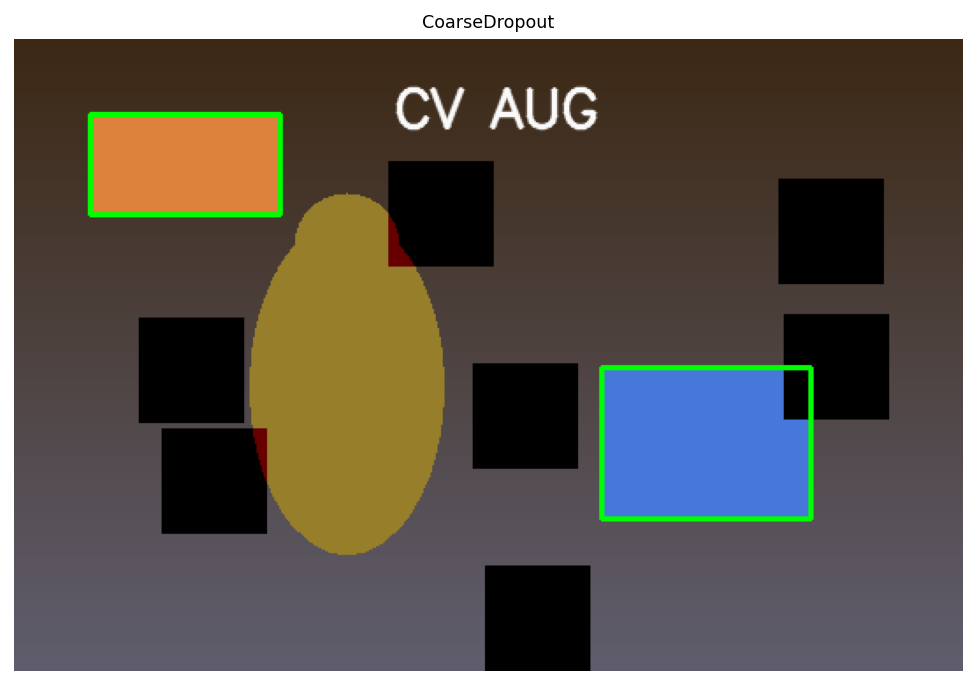

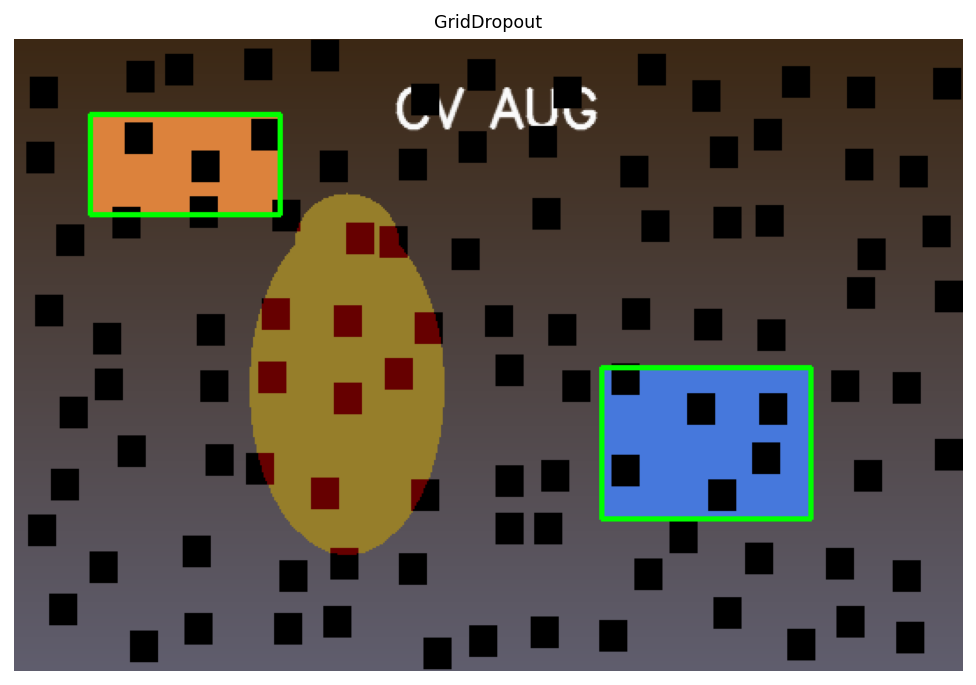

In [11]:
occlusions = [
    ("CoarseDropout", A.CoarseDropout(max_holes=10, max_height=60, max_width=60, min_holes=3, fill_value=0, p=1.0)),
    ("GridDropout", A.GridDropout(ratio=0.4, unit_size_min=30, unit_size_max=70, random_offset=True, p=1.0)),
]
for name, t in occlusions:
    show_aug(name, t)


### 2.6 Weather / illumination effects (optional)
Use only if your production data has these effects.


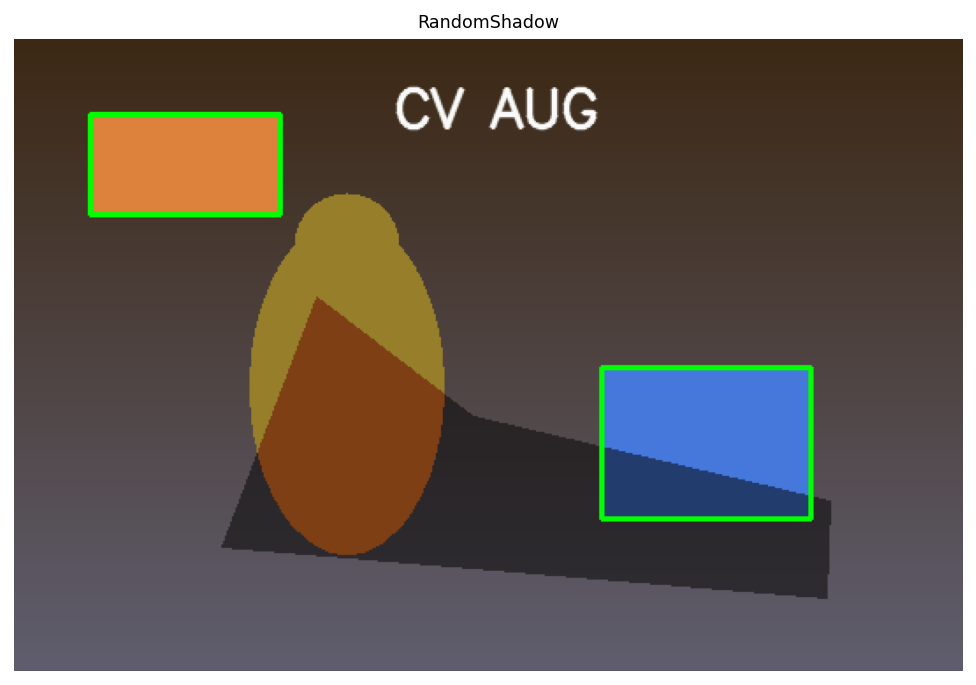

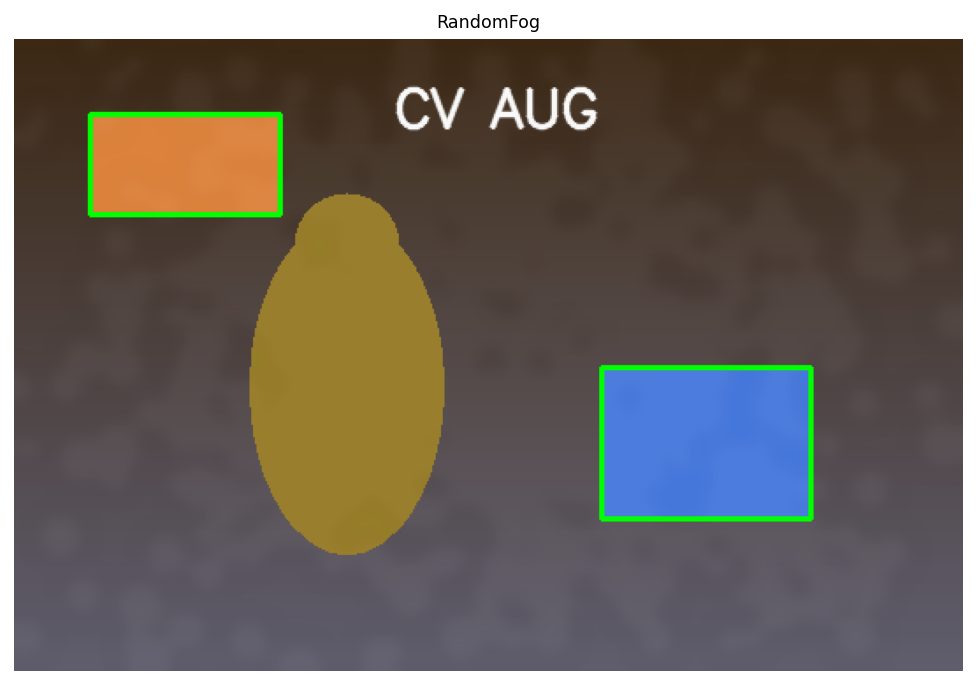

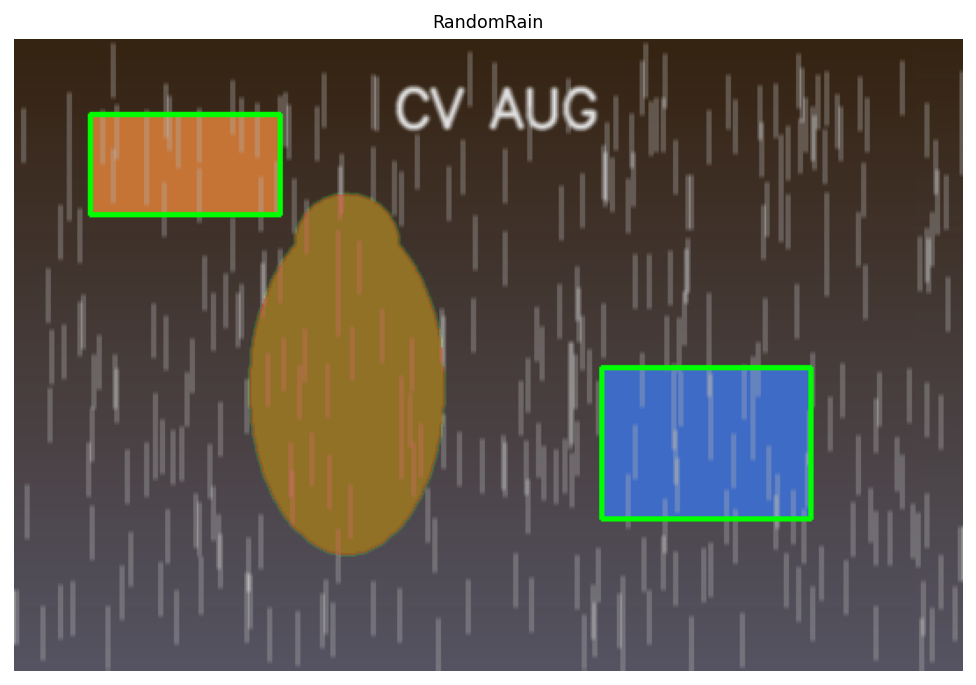

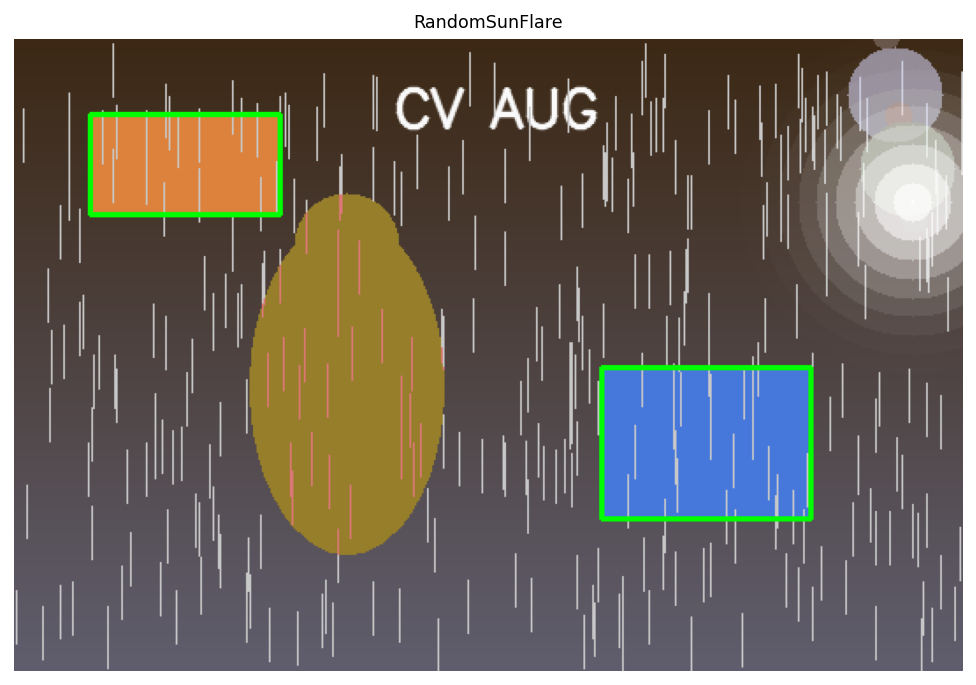

In [12]:
weather = [
    ("RandomShadow", A.RandomShadow(shadow_roi=(0, 0.3, 1, 0.95), num_shadows_lower=1, num_shadows_upper=2, shadow_dimension=5, p=1.0)),
    ("RandomFog", A.RandomFog(fog_coef_lower=0.2, fog_coef_upper=0.5, alpha_coef=0.08, p=1.0)),
    ("RandomRain", A.RandomRain(blur_value=3, brightness_coefficient=0.9, rain_type="heavy", p=1.0)),
    ("RandomSunFlare", A.RandomSunFlare(src_radius=120, flare_roi=(0, 0, 1, 0.5), p=1.0)),
]
for name, t in weather:
    show_aug(name, t)


## 3) Composed pipelines: “moderate” vs “aggressive”
A practical pattern: define two profiles, then validate with visualization and a small ablation run.


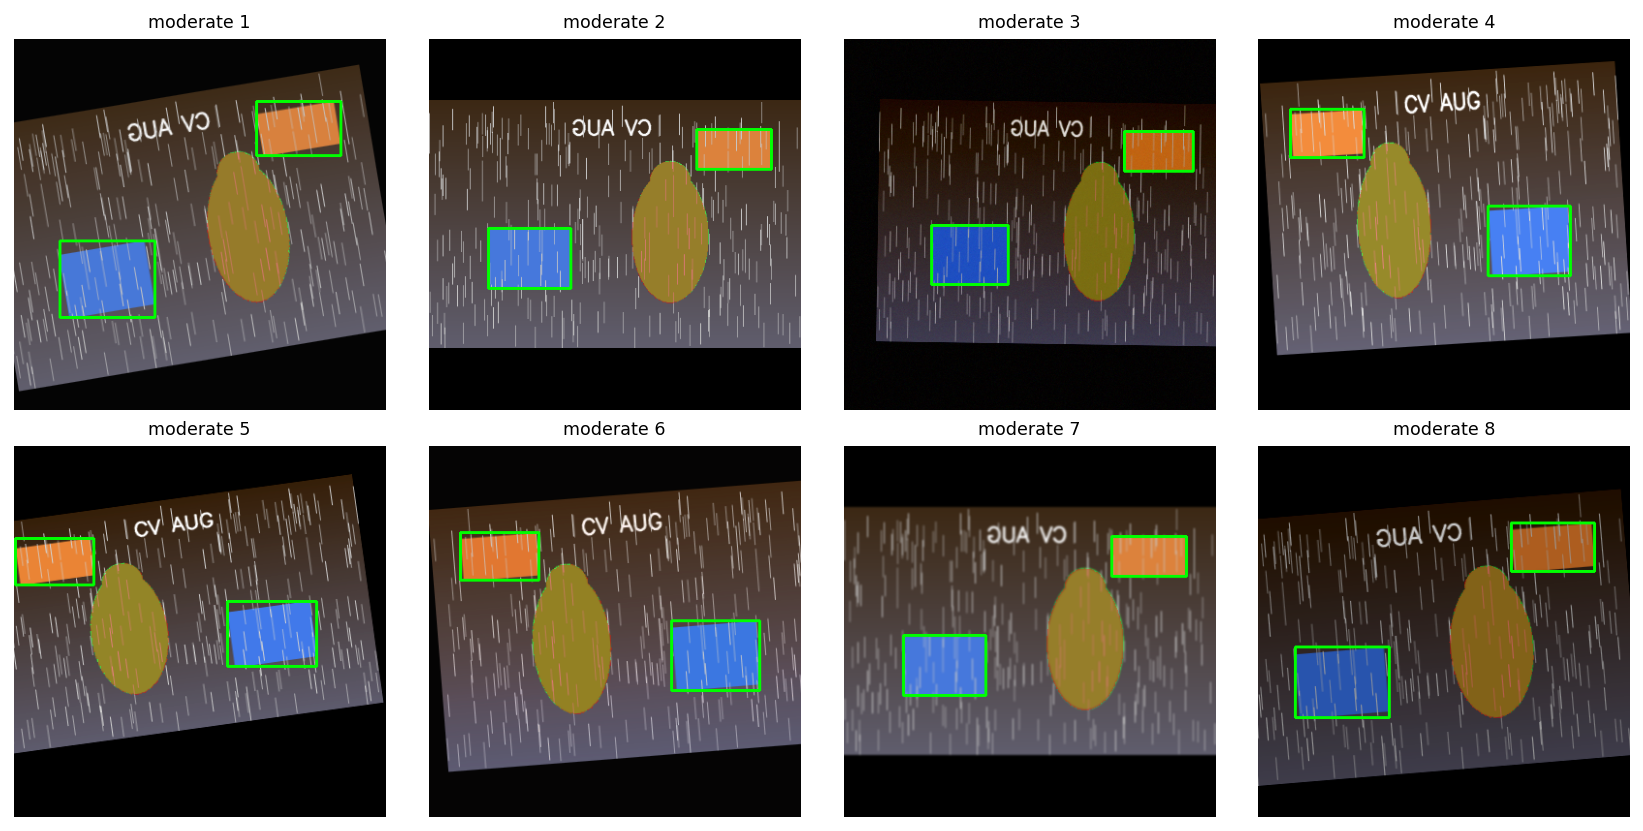

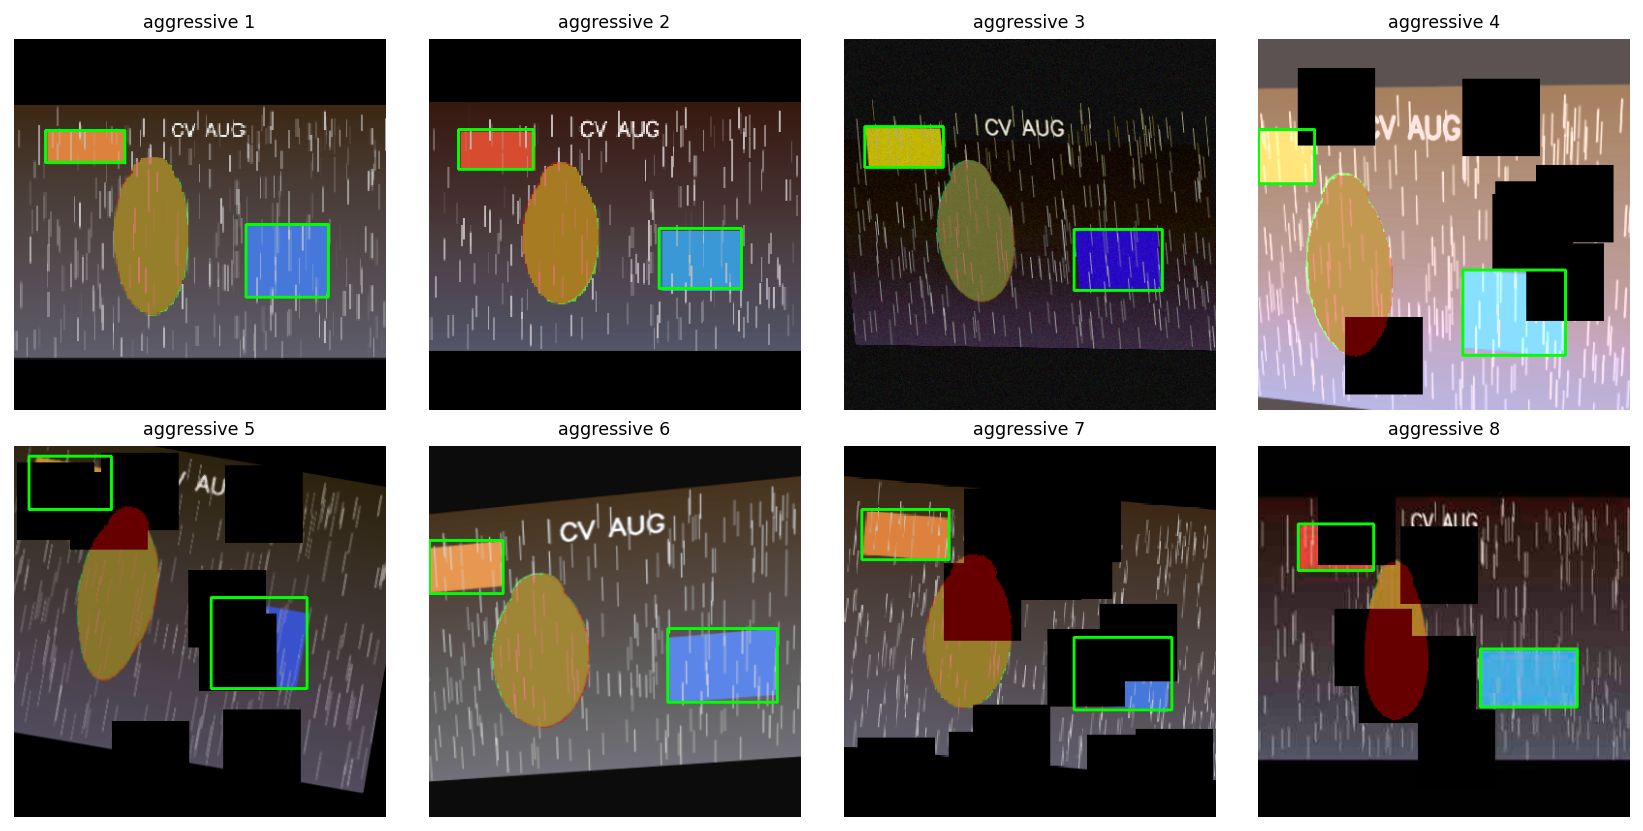

In [13]:
moderate = A.Compose([
    A.LongestMaxSize(max_size=384, p=1.0),
    A.PadIfNeeded(384, 384, border_mode=cv2.BORDER_CONSTANT, value=(0,0,0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=10, p=0.5, border_mode=cv2.BORDER_CONSTANT),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.5),
    A.HueSaturationValue(10, 15, 10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.GaussNoise(var_limit=(5.0, 30.0), p=0.15),
], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["labels"]))

aggressive = A.Compose([
    A.LongestMaxSize(max_size=384, p=1.0),
    A.PadIfNeeded(384, 384, border_mode=cv2.BORDER_CONSTANT, value=(0,0,0), p=1.0),
    A.OneOf([
        A.Affine(shear=(-15, 15), p=1.0, mode=cv2.BORDER_CONSTANT),
        A.Perspective(scale=(0.04, 0.12), p=1.0),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
    ], p=0.7),
    A.ShiftScaleRotate(shift_limit=0.10, scale_limit=0.20, rotate_limit=25, p=0.7, border_mode=cv2.BORDER_CONSTANT),
    A.RandomBrightnessContrast(0.30, 0.30, p=0.7),
    A.HueSaturationValue(18, 30, 18, p=0.6),
    A.OneOf([
        A.MotionBlur(blur_limit=15, p=1.0),
        A.GaussianBlur(blur_limit=(3, 9), p=1.0),
        A.MedianBlur(blur_limit=7, p=1.0),
    ], p=0.4),
    A.OneOf([
        A.GaussNoise(var_limit=(20.0, 120.0), p=1.0),
        A.ImageCompression(quality_lower=25, quality_upper=60, p=1.0),
        A.Downscale(scale_min=0.5, scale_max=0.75, p=1.0),
    ], p=0.5),
    A.CoarseDropout(max_holes=14, max_height=80, max_width=80, min_holes=6, fill_value=0, p=0.5),
], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["labels"]))

def sample_from_pipeline(pipeline, n=8):
    imgs = []
    for i in range(n):
        data = pipeline(image=img_rgb, mask=mask, bboxes=boxes_xyxy, labels=[0]*len(boxes_xyxy))
        vis = overlay_mask(draw_bboxes_rgb(data["image"], data["bboxes"]), data["mask"])
        imgs.append(vis)
    return imgs

show_images(sample_from_pipeline(moderate, n=8), titles=[f"moderate {i+1}" for i in range(8)], cols=4, figsize=(12, 6))
show_images(sample_from_pipeline(aggressive, n=8), titles=[f"aggressive {i+1}" for i in range(8)], cols=4, figsize=(12, 6))


## 4) MixUp / CutMix (manual)

These are **classification**-oriented. Not always suitable for detection/segmentation without special handling.


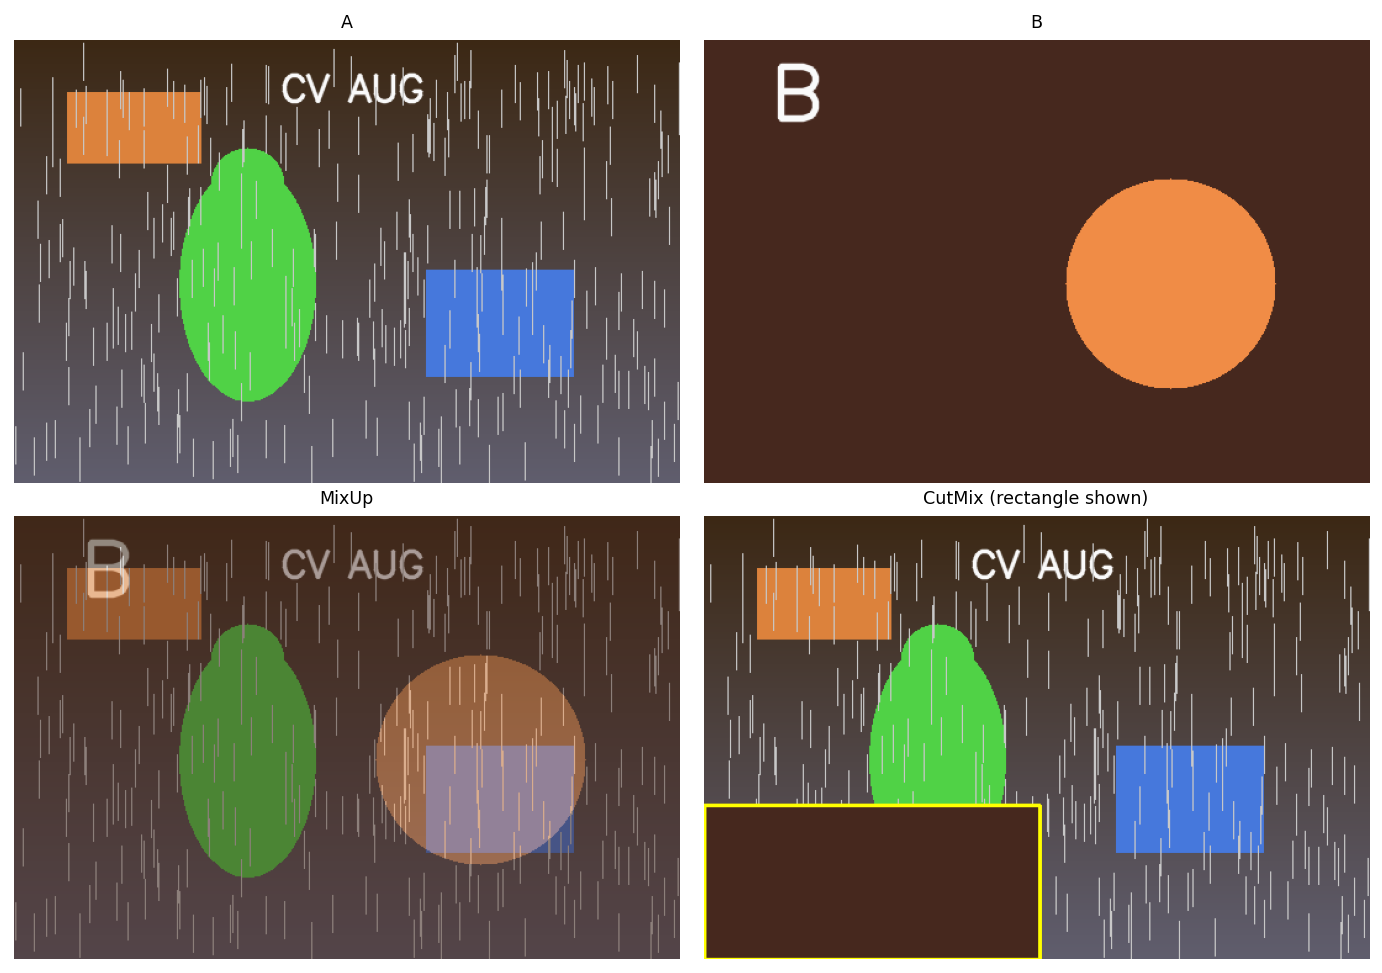

In [14]:
def make_second_scene(h=360, w=540):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[:] = (30, 40, 70)
    cv2.circle(img, (int(w*0.70), int(h*0.55)), 85, (70, 140, 240), -1)
    cv2.putText(img, "B", (int(w*0.10), int(h*0.18)), cv2.FONT_HERSHEY_SIMPLEX,
                2.0, (250, 250, 250), 3, cv2.LINE_AA)
    return bgr_to_rgb(img)

img2 = make_second_scene()

def mixup(img_a, img_b, alpha=0.55):
    return np.clip(alpha*img_a + (1-alpha)*img_b, 0, 255).astype(np.uint8)

def cutmix(img_a, img_b, lam=0.6):
    h, w = img_a.shape[:2]
    cut_w = int(w * np.sqrt(1 - lam))
    cut_h = int(h * np.sqrt(1 - lam))
    cx = np.random.randint(w)
    cy = np.random.randint(h)
    x1 = int(np.clip(cx - cut_w // 2, 0, w))
    y1 = int(np.clip(cy - cut_h // 2, 0, h))
    x2 = int(np.clip(cx + cut_w // 2, 0, w))
    y2 = int(np.clip(cy + cut_h // 2, 0, h))
    out = img_a.copy()
    out[y1:y2, x1:x2] = img_b[y1:y2, x1:x2]
    return out, (x1, y1, x2, y2)

mx = mixup(img_rgb, img2, alpha=0.55)
cm, rect = cutmix(img_rgb, img2, lam=0.6)
cm_vis = cm.copy()
cv2.rectangle(cm_vis, (rect[0], rect[1]), (rect[2], rect[3]), (255, 255, 0), 2)

show_images([img_rgb, img2, mx, cm_vis],
            titles=["A", "B", "MixUp", "CutMix (rectangle shown)"],
            cols=2, figsize=(10, 7))


## 5) Validation checklist (use this in real projects)

- Visual sanity-check (8–32 samples)
- Does the task remain the same? (labels still correct?)
- Train transforms ≠ Eval transforms
- Ablation: baseline vs +aug (one change at a time)
- Track errors: failure modes, false positives, false negatives


In [15]:
print("Albumentations version:", A.__version__)
print("Reminder: Keep augmentation profiles versioned like code.")


Albumentations version: 1.4.18
Reminder: Keep augmentation profiles versioned like code.
